# ARIMA Time Series Forecasting — TSLA

---

| Section | What we do |
|---------|------------|
| 1 | Load & save TSLA price data (2015–2026) |
| 2 | Test stationarity (ADF test) |
| 3 | Select ARIMA parameters (auto_arima) |
| 4 | Train/test split & fit ARIMA on returns |
| 5 | Forecast prices with confidence cone |
| 6 | Evaluate accuracy (MAE, RMSE, MAPE) |
| 7 | Save forecast output for Task 4 |

In [1]:
import sys, pathlib
cwd = pathlib.Path('.').resolve()
if (cwd / 'src').exists():
    sys.path.insert(0, str(cwd))
else:
    p = cwd
    while p.parent != p:
        p = p.parent
        if (p / 'src').exists():
            sys.path.insert(0, str(p))
            break

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from src.arima_utils import (
    fetch_and_save, save_series, adf_report,
    find_best_order, fit_arima, forecast_with_confidence, evaluate_forecast
)

plt.rcParams['figure.dpi'] = 120
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

TICKER = 'TSLA'
START_DATE = '2015-01-01'
END_DATE = '2026-06-30'
TRAIN_END = '2024-12-31'

print(f'Ticker: {TICKER} | {START_DATE} -> {END_DATE} | train ends {TRAIN_END}')

Ticker: TSLA | 2015-01-01 -> 2026-06-30 | train ends 2024-12-31


---
## Section 1 — Load & Save Data

Fetches TSLA via yfinance if not already cached locally, saves raw OHLCV to
`data/raw/`, and confirms the save actually landed on disk before continuing.

In [2]:
price = fetch_and_save(TICKER, START_DATE, END_DATE)
returns = price.pct_change().dropna()

save_series(price, f'{TICKER}_close.csv')
save_series(returns, f'{TICKER}_returns.csv')

print(f'\nLoaded {len(price)} trading days')
print(f'Date range : {price.index.min().date()} -> {price.index.max().date()}')
print(f'Price range: ${price.min():.2f} -> ${price.max():.2f}')

[*********************100%***********************]  1 of 1 completed

  Saved raw data -> ../data/raw/TSLA_raw.csv  (2888 rows)
  Saved -> ../data/processed/TSLA_close.csv  (2888 rows)
  Saved -> ../data/processed/TSLA_returns.csv  (2887 rows)

Loaded 2888 trading days
Date range : 2015-01-02 -> 2026-06-29
Price range: $9.58 -> $489.88


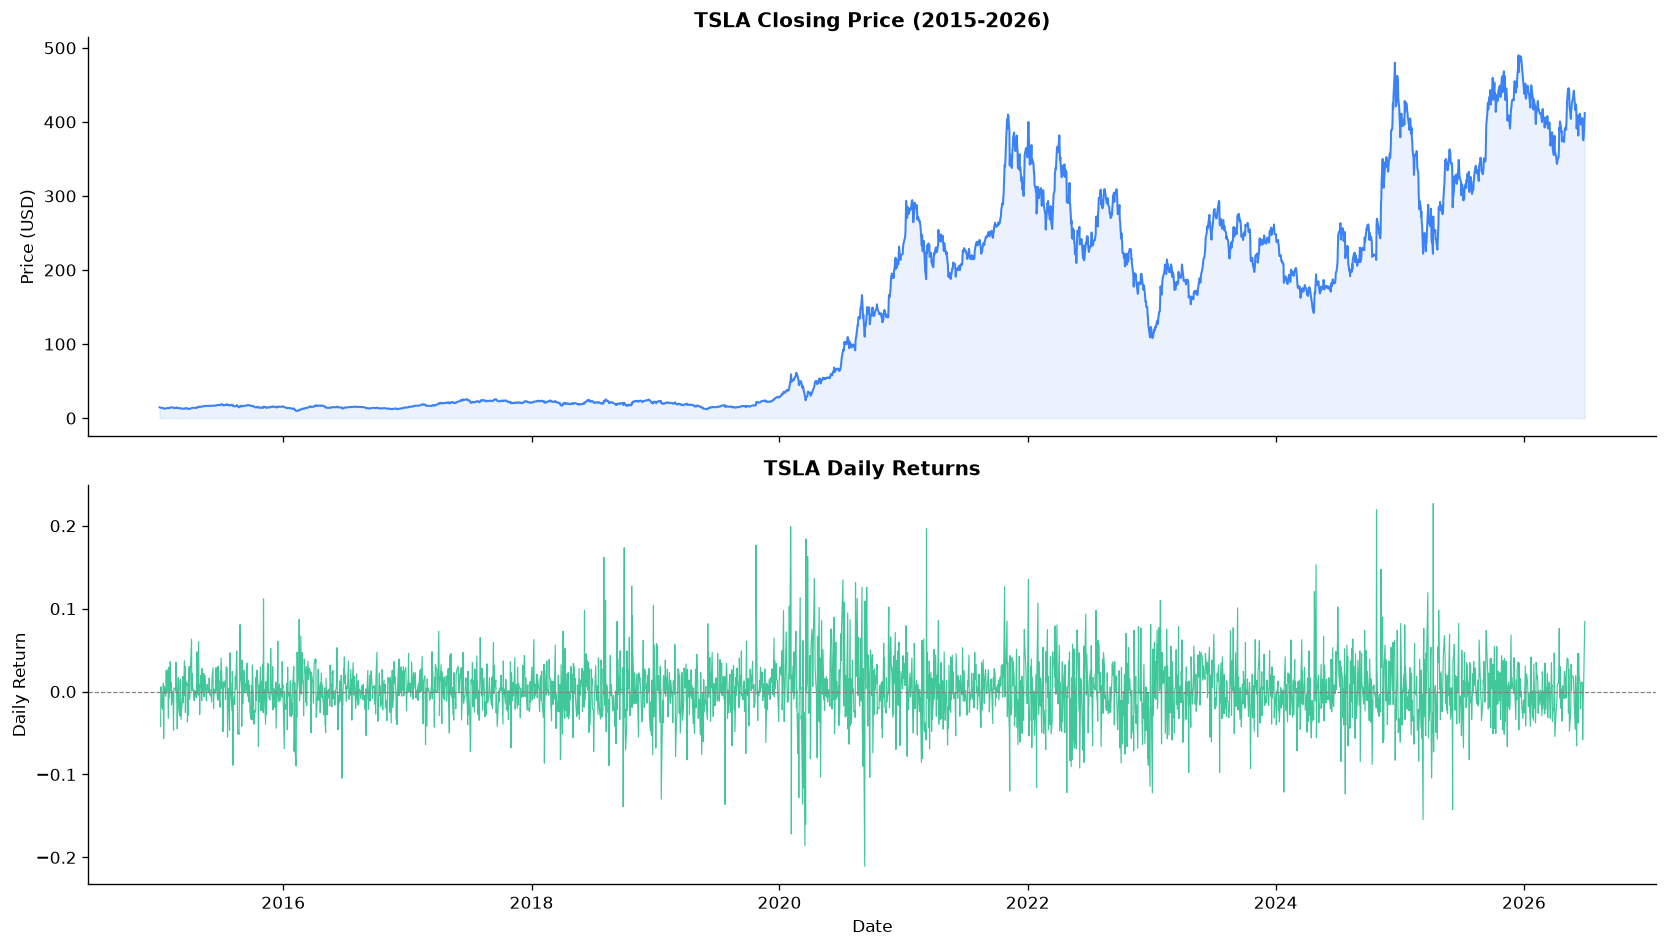

Summary statistics:
count    2887.0000
mean        0.0018
std         0.0360
min        -0.2106
25%        -0.0166
50%         0.0012
75%         0.0195
max         0.2269
Name: Close, dtype: float64


In [3]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

axes[0].plot(price, color='#3B82F6', linewidth=1.2)
axes[0].fill_between(price.index, price, alpha=0.1, color='#3B82F6')
axes[0].set_title(f'{TICKER} Closing Price (2015-2026)', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Price (USD)')

axes[1].plot(returns, color='#10B981', linewidth=0.7, alpha=0.8)
axes[1].axhline(0, color='gray', linewidth=0.7, linestyle='--')
axes[1].set_title(f'{TICKER} Daily Returns', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Daily Return')
axes[1].set_xlabel('Date')

plt.tight_layout()
plt.show()

print('Summary statistics:')
print(returns.describe().round(4))

---
## Section 2 — Stationarity Testing

ARIMA requires stationary input. We expect raw price to be non-stationary
(trends upward) and returns to be stationary (oscillate around 0).

In [4]:
print('--- ADF Test Results ---')
p_close = adf_report(price, 'TSLA Price')
p_returns = adf_report(returns, 'TSLA Returns')

print()
print(f"Conclusion: {'price is non-stationary as expected' if p_close >= 0.05 else 'unexpected: price looks stationary'}, "
      f"{'returns are stationary as expected' if p_returns < 0.05 else 'unexpected: returns look non-stationary'}.")
print('-> Model ARIMA on RETURNS with d=0, then convert forecasts back to prices.')

--- ADF Test Results ---
  TSLA Price           ADF stat= -1.0696  p=0.727042  ->  NON-STATIONARY
  TSLA Returns         ADF stat=-53.9719  p=0.000000  ->  STATIONARY

Conclusion: price is non-stationary as expected, returns are stationary as expected.
-> Model ARIMA on RETURNS with d=0, then convert forecasts back to prices.


---
## Section 3 — Select ARIMA Parameters

We use `auto_arima` (pmdarima) to search (p, d, q) combinations and pick the
one with the lowest AIC. ACF/PACF plots are shown alongside for visual
justification in the report.

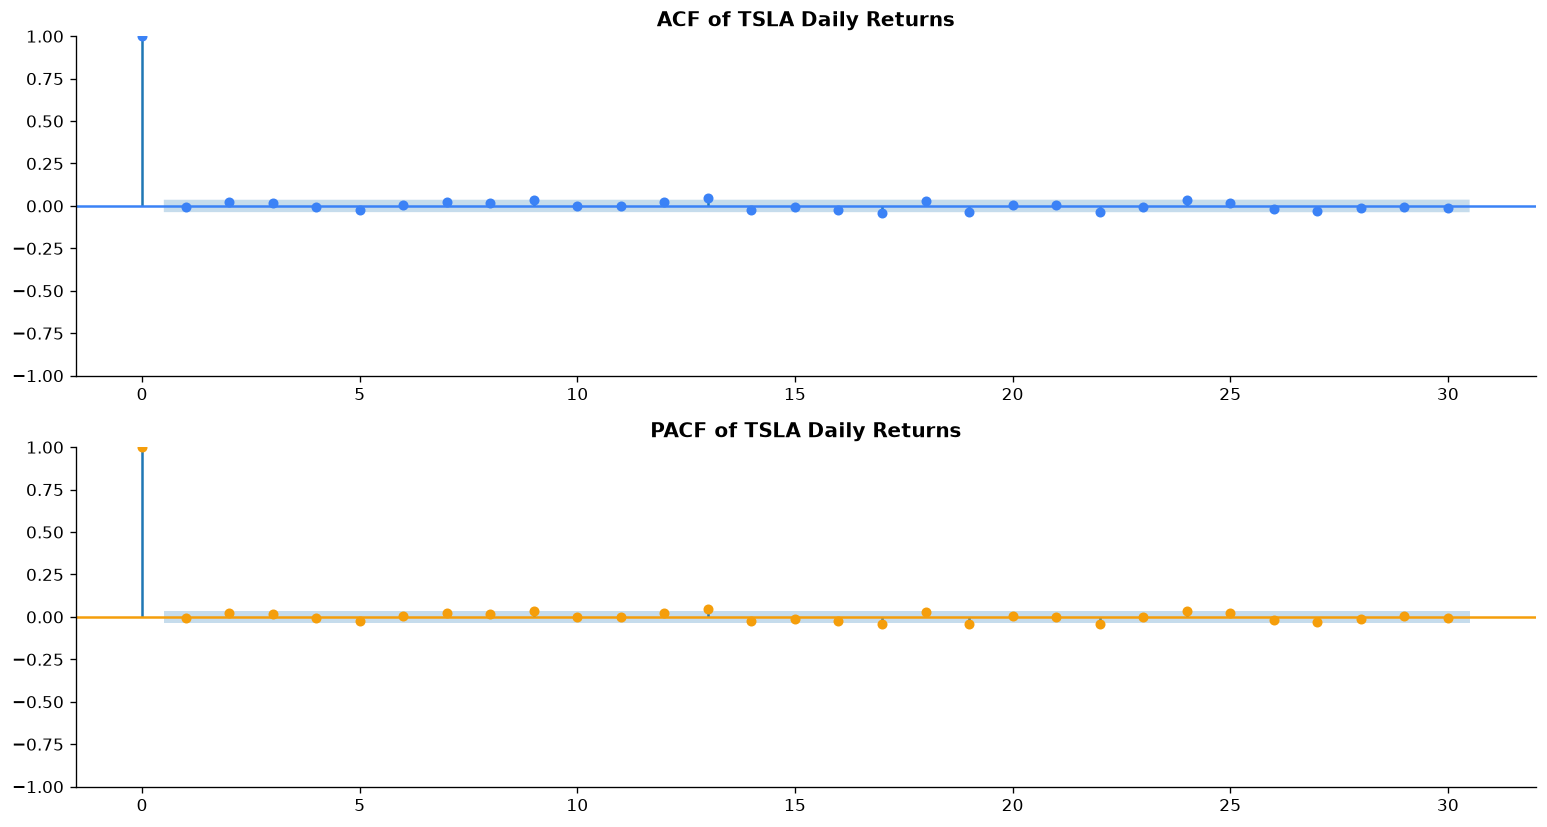

In [5]:
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 7))
plot_acf(returns, lags=30, ax=ax1, color='#3B82F6')
ax1.set_title('ACF of TSLA Daily Returns', fontsize=12, fontweight='bold')
plot_pacf(returns, lags=30, ax=ax2, color='#F59E0B', method='ywm')
ax2.set_title('PACF of TSLA Daily Returns', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

In [6]:
train_returns_full = returns.loc[:TRAIN_END]
best_order = find_best_order(train_returns_full)
print(f'\nSelected order (p,d,q) = {best_order}')

  auto_arima selected order: (0, 0, 0)  (AIC=-9579.44)

Selected order (p,d,q) = (0, 0, 0)


---
## Section 4 — Train/Test Split & Fit ARIMA

Chronological split only — no shuffling, to avoid leaking future data into
training.

In [7]:
train_price = price.loc[:TRAIN_END]
test_price = price.loc[TRAIN_END:].iloc[1:]
train_returns = returns.loc[:TRAIN_END]
test_returns = returns.loc[TRAIN_END:].iloc[1:]

print(f'Training: {len(train_price):4d} days  ({train_price.index[0].date()} -> {train_price.index[-1].date()})')
print(f'Test    : {len(test_price):4d} days  ({test_price.index[0].date()} -> {test_price.index[-1].date()})')

Training: 2516 days  (2015-01-02 -> 2024-12-31)
Test    :  372 days  (2025-01-02 -> 2026-06-29)


In [8]:
print(f'Fitting ARIMA{best_order} on TSLA training returns...')
model_fit = fit_arima(train_returns, best_order)
print(model_fit.summary())

Fitting ARIMA(0, 0, 0) on TSLA training returns...


c:\projects\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\projects\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)
c:\projects\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


                               SARIMAX Results                                
Dep. Variable:                  Close   No. Observations:                 2515
Model:                          ARIMA   Log Likelihood                4791.720
Date:                Tue, 07 Jul 2026   AIC                          -9579.440
Time:                        23:18:48   BIC                          -9567.780
Sample:                             0   HQIC                         -9575.208
                               - 2515                                         
Covariance Type:                  opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0020      0.001      2.716      0.007       0.001       0.003
sigma2         0.0013   2.06e-05     62.991      0.000       0.001       0.001
Ljung-Box (L1) (Q):                   0.00   Jarque-

---
## Section 5 — Forecast & Convert to Prices

Forecast returns -> compound into a price path -> build a 95% confidence
cone using sqrt(t) scaling (correct for a random-walk process; see notebook
discussion for why sqrt(t) rather than linear compounding of daily bounds).

In [9]:
n_steps = len(test_returns)
last_train_price = float(train_price.iloc[-1])

fc_returns, fc_prices_central, fc_lower, fc_upper = forecast_with_confidence(
    model_fit, train_returns, last_train_price, n_steps
)
fc_price_series = pd.Series(fc_prices_central, index=test_returns.index)

print(f'Last known price: ${last_train_price:.2f}')
print(f'{"Horizon":>10}  {"Forecast":>10}  {"Lower":>9}  {"Upper":>9}  {"Band Width":>11}')
print('-' * 56)
for d in [1, 5, 20, 60, n_steps - 1]:
    print(f'{d:>10}d  ${fc_prices_central[d]:>9.2f}  ${fc_lower[d]:>8.2f}  '
          f'${fc_upper[d]:>8.2f}  ${fc_upper[d]-fc_lower[d]:>10.2f}')

Last known price: $403.84
   Horizon    Forecast      Lower      Upper   Band Width
--------------------------------------------------------
         1d  $   405.43  $  365.12  $  445.73  $     80.62
         5d  $   408.61  $  338.80  $  478.43  $    139.63
        20d  $   420.80  $  290.19  $  551.41  $    261.22
        60d  $   455.10  $  232.49  $  677.70  $    445.21
       371d  $   836.90  $  287.18  $ 1386.62  $   1099.45


c:\projects\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: ValueWarning: No supported index is available. Prediction results will be given with an integer index beginning at `start`.
  return get_prediction_index(
c:\projects\portfolio-optimization\.venv\Lib\site-packages\statsmodels\tsa\base\tsa_model.py:837: FutureWarning: No supported index is available. In the next version, calling this method in a model without a supported index will result in an exception.
  return get_prediction_index(


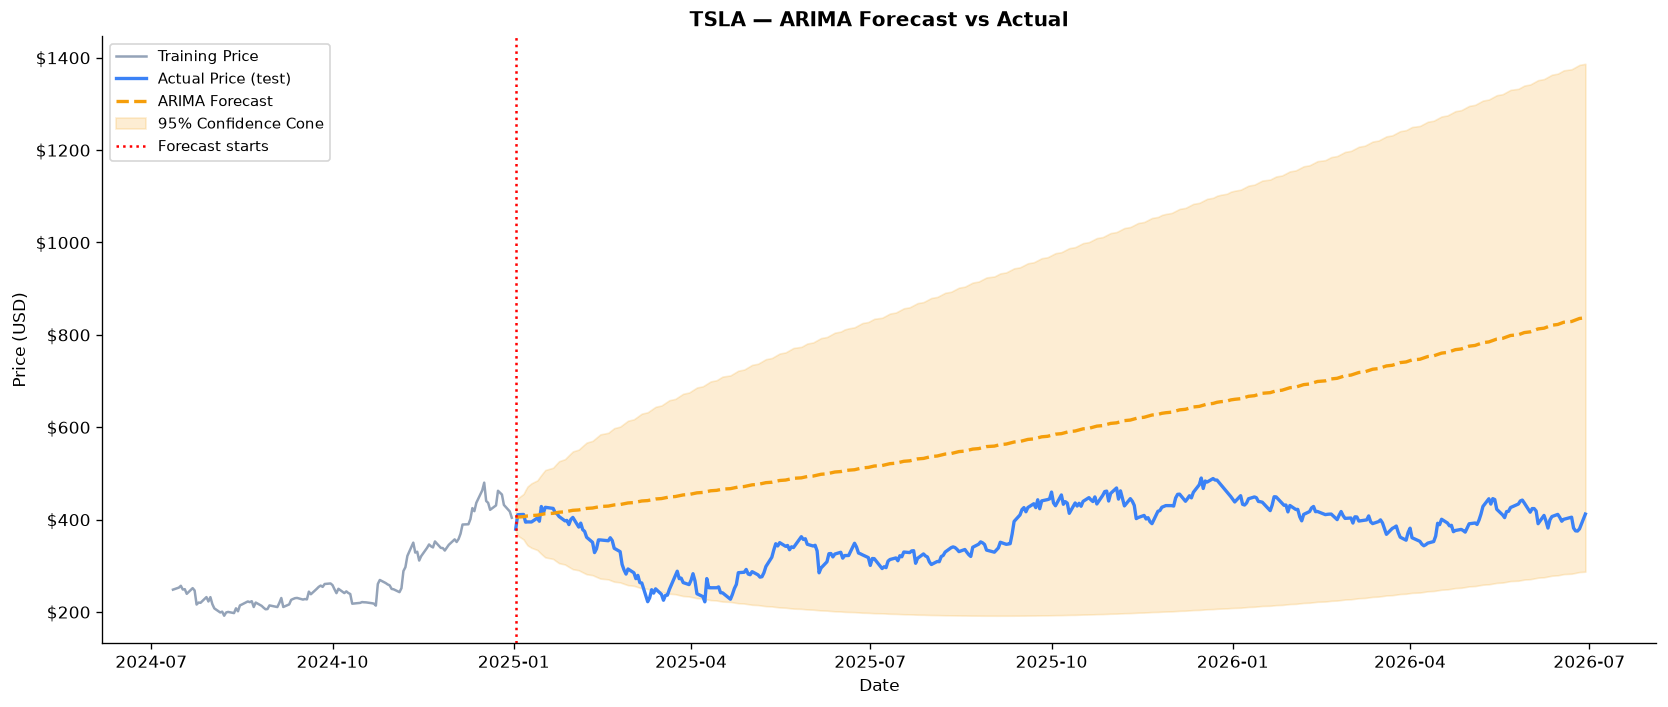

In [10]:
fig, ax = plt.subplots(figsize=(14, 6))

hist = train_price.iloc[-120:]
ax.plot(hist.index, hist.values, color='#94A3B8', lw=1.5, label='Training Price')
ax.plot(test_price.index, test_price.values, color='#3B82F6', lw=2.0, label='Actual Price (test)')
ax.plot(test_returns.index, fc_prices_central, color='#F59E0B', lw=2.0, linestyle='--', label='ARIMA Forecast')
ax.fill_between(test_returns.index, fc_lower, fc_upper, alpha=0.18, color='#F59E0B', label='95% Confidence Cone')
ax.axvline(test_returns.index[0], color='red', lw=1.5, linestyle=':', label='Forecast starts')

ax.set_title(f'{TICKER} — ARIMA Forecast vs Actual', fontsize=12, fontweight='bold')
ax.set_ylabel('Price (USD)')
ax.set_xlabel('Date')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'${y:.0f}'))
ax.legend(fontsize=9, loc='upper left')
plt.tight_layout()
plt.show()

---
## Section 6 — Evaluate Forecast Accuracy

In [11]:
actual_aligned = test_price.reindex(fc_price_series.index).dropna()
fc_aligned = fc_price_series.reindex(actual_aligned.index)

metrics = evaluate_forecast(actual_aligned, fc_aligned)

print('=' * 45)
print(f'  ARIMA{best_order} — TSLA Forecast Metrics')
print('=' * 45)
print(f"  MAE  : ${metrics['MAE']:.2f}")
print(f"  RMSE : ${metrics['RMSE']:.2f}")
print(f"  MAPE : {metrics['MAPE']:.2f}%")

  ARIMA(0, 0, 0) — TSLA Forecast Metrics
  MAE  : $222.57
  RMSE : $245.05
  MAPE : 61.25%


---
## Section 7 — Save Forecast Output for Task 4

Task 4's portfolio optimization notebook needs the ARIMA-forecasted return
for TSLA. We save it here rather than re-running ARIMA inside that notebook.

In [13]:
forecast_output = pd.DataFrame({
    'Date': test_returns.index,
    'Actual_Price': test_price.reindex(test_returns.index).values,
    'Forecast_Price': fc_prices_central,
    'Lower_CI': fc_lower,
    'Upper_CI': fc_upper,
    'Forecast_Return': fc_returns,
})
save_series(forecast_output.set_index('Date')['Forecast_Return'], 'tsla_arima_forecast_returns.csv')
forecast_output.to_csv('../data/processed/tsla_arima_forecast_full.csv', index=False)

print('Saved forecast output for use in Task 4 portfolio optimization.')
print(f"ARIMA-implied annualized TSLA return: {fc_returns.mean() * 252 * 100:.2f}%")

  Saved -> ../data/processed/tsla_arima_forecast_returns.csv  (372 rows)
Saved forecast output for use in Task 4 portfolio optimization.
ARIMA-implied annualized TSLA return: 49.41%
